In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import (
    RandomForestClassifier, RandomForestRegressor,
    GradientBoostingClassifier, GradientBoostingRegressor,
    VotingClassifier,
)
from sklearn.linear_model import LogisticRegression, Ridge
from sklearn.multioutput import ClassifierChain, MultiOutputClassifier
from sklearn.metrics import (
    accuracy_score, f1_score, hamming_loss,
    mean_absolute_error, r2_score, classification_report,
)
from sklearn.model_selection import (
    RandomizedSearchCV, StratifiedKFold, train_test_split,
)
from sklearn.preprocessing import StandardScaler, LabelEncoder

try:
    from xgboost import XGBClassifier, XGBRegressor
    print("✓ XGBoost imported")
except ImportError:
    import subprocess, sys
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "xgboost"])
    from xgboost import XGBClassifier, XGBRegressor
    print("✓ XGBoost installed + imported")

sns.set_theme(style="whitegrid", context="notebook")
RANDOM_STATE = 42
print("✓ All imports successful\n")


✓ XGBoost imported
✓ All imports successful



In [2]:
# BLOCK 1 — Load Data
DATA_PATH = "irrigation_synthetic_dataset.csv"
df = pd.read_csv(DATA_PATH)
df.columns = df.columns.str.strip()
print(f"{df.shape[0]} rows × {df.shape[1]} cols")
print(f"  Columns: {list(df.columns)}\n")

df = df.drop(columns=["timestamp"], errors="ignore")

4000 rows × 25 cols
  Columns: ['timestamp', 'temperature', 'humidity', 'soil_moisture', 'soil_ph', 'water_tds', 'solar_radiation', 'wind_speed', 'rainfall_last_24h', 'time_since_irrigation', 'leaf_temperature', 'crop_type', 'growth_stage', 'needs_irrigation', 'overwatered', 'drought_stress', 'high_et', 'optimal_moisture', 'ph_stress', 'poor_water_quality', 'heat_stress', 'low_humidity_stress', 'healthy', 'valve_on_minutes', 'label']



In [3]:
# BLOCK 2 — Feature Engineering
NUMERIC_FEATURES = [
    "temperature", "humidity", "soil_moisture", "soil_ph", "water_tds",
    "solar_radiation", "wind_speed", "rainfall_last_24h",
    "time_since_irrigation", "leaf_temperature",
]

# One-hot encode categorical columns
df = pd.get_dummies(df, columns=["crop_type", "growth_stage"], drop_first=False)
cat_features = [c for c in df.columns if c.startswith("crop_type_")
                or c.startswith("growth_stage_")]
FEATURE_COLS = NUMERIC_FEATURES + cat_features

LABEL_COLS = [
    "needs_irrigation", "overwatered", "drought_stress", "high_et",
    "optimal_moisture", "ph_stress", "poor_water_quality",
    "heat_stress", "low_humidity_stress", "healthy",
]
REGRESSION_TARGET = "valve_on_minutes"

X = df[FEATURE_COLS].copy()
Y = df[LABEL_COLS].copy()
y_reg = df[REGRESSION_TARGET].copy()

print(f"Features : {X.shape[1]}  |  Labels : {Y.shape[1]}")
print(f"Label prevalence:")
for c in LABEL_COLS:
    n = Y[c].sum()
    print(f"  {c:<26}: {n:4d} ({n/len(Y)*100:.1f}%)")

Features : 19  |  Labels : 10
Label prevalence:
  needs_irrigation          :  967 (24.2%)
  overwatered               :  462 (11.6%)
  drought_stress            :  526 (13.2%)
  high_et                   :  265 (6.6%)
  optimal_moisture          : 2472 (61.8%)
  ph_stress                 : 1263 (31.6%)
  poor_water_quality        :   56 (1.4%)
  heat_stress               :  909 (22.7%)
  low_humidity_stress       :  574 (14.3%)
  healthy                   : 1246 (31.1%)


In [4]:
# BLOCK 3 — Train / Test Split & Scaling
X_tr, X_te, Y_tr, Y_te, yr_tr, yr_te = train_test_split(
    X, Y, y_reg,
    test_size=0.20, random_state=RANDOM_STATE,
    stratify=Y["needs_irrigation"],   # stratify on the key label
)

scaler    = StandardScaler()
X_tr_s    = scaler.fit_transform(X_tr)
X_te_s    = scaler.transform(X_te)

print(f"\nTrain : {X_tr_s.shape}  |  Test : {X_te_s.shape}")


Train : (3200, 19)  |  Test : (800, 19)


In [5]:
# BLOCK 4 — Evaluation Helpers
def eval_multilabel(model, X_tr, Y_tr, X_te, Y_te, name):
    model.fit(X_tr, Y_tr)
    tr_pred = model.predict(X_tr)
    te_pred = model.predict(X_te)
    tr_exact = accuracy_score(Y_tr, tr_pred)
    te_exact = accuracy_score(Y_te, te_pred)
    tr_f1    = f1_score(Y_tr, tr_pred, average="macro", zero_division=0)
    te_f1    = f1_score(Y_te, te_pred, average="macro", zero_division=0)
    te_hl    = hamming_loss(Y_te, te_pred)
    gap      = tr_exact - te_exact

    print(f"\n{'='*62}\n  {name}\n{'='*62}")
    print(f"  Exact Match  — Train: {tr_exact:.4f}  |  Test: {te_exact:.4f}")
    print(f"  Macro F1     — Train: {tr_f1:.4f}  |  Test: {te_f1:.4f}")
    print(f"  Hamming Loss          : {te_hl:.4f}")
    print(f"  Overfit Gap           : {gap:.4f}  "
          f"{'⚠️  Check' if gap > 0.06 else '✓ OK'}")
    return {"Model": name, "Train Exact": tr_exact, "Test Exact": te_exact,
            "Train F1": tr_f1, "Test F1": te_f1, "Hamming Loss": te_hl,
            "Overfit Gap": gap, "_model": model, "_pred": te_pred}


def eval_regression(model, X_tr, y_tr, X_te, y_te, name):
    model.fit(X_tr, y_tr)
    tr_pred = model.predict(X_tr)
    te_pred = model.predict(X_te)
    tr_mae  = mean_absolute_error(y_tr, tr_pred)
    te_mae  = mean_absolute_error(y_te, te_pred)
    te_r2   = r2_score(y_te, te_pred)
    gap     = tr_mae - te_mae      # negative = test harder (normal)

    print(f"\n{'='*62}\n  REGRESSION — {name}\n{'='*62}")
    print(f"  MAE  — Train: {tr_mae:.2f} min  |  Test: {te_mae:.2f} min")
    print(f"  R²   — Test : {te_r2:.4f}")
    return {"Model": name, "Train MAE": tr_mae, "Test MAE": te_mae,
            "Test R2": te_r2, "_pred": te_pred}

In [6]:
# BLOCK 5 — Random Forest (multi-label)
print("RANDOM FOREST\n")

rf_params = {"n_estimators":[100,150], "max_depth":[8,12],
             "min_samples_split":[8,15], "min_samples_leaf":[4,8],
             "max_features":["sqrt"]}
rf_search = RandomizedSearchCV(
    RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=-1),
    rf_params, n_iter=8, cv=3, scoring="f1_macro",
    random_state=RANDOM_STATE, n_jobs=-1
)
rf_search.fit(X_tr_s, Y_tr.iloc[:,0])
best_rf = rf_search.best_params_
print(f"Best RF params: {best_rf}")

rf_clf  = MultiOutputClassifier(
    RandomForestClassifier(**best_rf, random_state=RANDOM_STATE, n_jobs=-1), n_jobs=-1)
rf_res  = eval_multilabel(rf_clf, X_tr_s, Y_tr, X_te_s, Y_te, "Random Forest")


RANDOM FOREST

Best RF params: {'n_estimators': 100, 'min_samples_split': 8, 'min_samples_leaf': 4, 'max_features': 'sqrt', 'max_depth': 12}

  Random Forest
  Exact Match  — Train: 0.9316  |  Test: 0.8425
  Macro F1     — Train: 0.9865  |  Test: 0.9551
  Hamming Loss          : 0.0222
  Overfit Gap           : 0.0891  ⚠️  Check


In [7]:
# BLOCK 6 — Gradient Boosting (multi-label)
print("GRADIENT BOOSTING\n")

gb_params = {"n_estimators":[100,150], "learning_rate":[0.05,0.1],
             "max_depth":[3,5], "min_samples_split":[8,15],
             "min_samples_leaf":[4,8], "subsample":[0.7,0.85]}
gb_search = RandomizedSearchCV(
    GradientBoostingClassifier(random_state=RANDOM_STATE),
    gb_params, n_iter=8, cv=3, scoring="f1",
    random_state=RANDOM_STATE, n_jobs=-1
)
gb_search.fit(X_tr_s, Y_tr.iloc[:,0])
best_gb = gb_search.best_params_
print(f"Best GB params: {best_gb}")

gb_clf  = MultiOutputClassifier(
    GradientBoostingClassifier(**best_gb, random_state=RANDOM_STATE), n_jobs=-1)
gb_res  = eval_multilabel(gb_clf, X_tr_s, Y_tr, X_te_s, Y_te, "Gradient Boosting")


GRADIENT BOOSTING

Best GB params: {'subsample': 0.7, 'n_estimators': 100, 'min_samples_split': 15, 'min_samples_leaf': 4, 'max_depth': 5, 'learning_rate': 0.1}

  Gradient Boosting
  Exact Match  — Train: 0.9991  |  Test: 0.9812
  Macro F1     — Train: 0.9998  |  Test: 0.9955
  Hamming Loss          : 0.0024
  Overfit Gap           : 0.0178  ✓ OK


In [8]:
# BLOCK 7 — XGBoost (multi-label)
print("\nXGBOOST\n")

xgb_params = {"n_estimators":[100,150], "learning_rate":[0.05,0.1],
              "max_depth":[4,6], "min_child_weight":[4,8],
              "subsample":[0.7,0.85], "colsample_bytree":[0.7,0.85],
              "gamma":[0.1,0.3], "reg_alpha":[0.1,0.5], "reg_lambda":[1.0,2.0]}
xgb_search = RandomizedSearchCV(
    XGBClassifier(random_state=RANDOM_STATE, n_jobs=-1,
                  eval_metric="logloss", use_label_encoder=False),
    xgb_params, n_iter=15, cv=3, scoring="f1",
    random_state=RANDOM_STATE, n_jobs=-1
)
xgb_search.fit(X_tr_s, Y_tr.iloc[:,0])
best_xgb = xgb_search.best_params_
print(f"Best XGB params: {best_xgb}")

xgb_clf = MultiOutputClassifier(
    XGBClassifier(**best_xgb, random_state=RANDOM_STATE, n_jobs=-1,
                  eval_metric="logloss", use_label_encoder=False), n_jobs=-1)
xgb_res = eval_multilabel(xgb_clf, X_tr_s, Y_tr, X_te_s, Y_te, "XGBoost")


XGBOOST

Best XGB params: {'subsample': 0.85, 'reg_lambda': 2.0, 'reg_alpha': 0.5, 'n_estimators': 150, 'min_child_weight': 4, 'max_depth': 6, 'learning_rate': 0.1, 'gamma': 0.3, 'colsample_bytree': 0.85}

  XGBoost
  Exact Match  — Train: 0.9909  |  Test: 0.9663
  Macro F1     — Train: 0.9950  |  Test: 0.9782
  Hamming Loss          : 0.0045
  Overfit Gap           : 0.0247  ✓ OK


In [9]:
# BLOCK 8 — Logistic Regression baseline
print("LOGISTIC REGRESSION (baseline)\n")

lr_clf = MultiOutputClassifier(
    LogisticRegression(C=0.5, max_iter=1000, random_state=RANDOM_STATE), n_jobs=-1)
lr_res = eval_multilabel(lr_clf, X_tr_s, Y_tr, X_te_s, Y_te,
                         "Logistic Regression (baseline)")

LOGISTIC REGRESSION (baseline)


  Logistic Regression (baseline)
  Exact Match  — Train: 0.3347  |  Test: 0.3137
  Macro F1     — Train: 0.7791  |  Test: 0.7673
  Hamming Loss          : 0.0924
  Overfit Gap           : 0.0209  ✓ OK


In [10]:
# BLOCK 9 — Voting Ensemble
print("VOTING ENSEMBLE\n")

voting = MultiOutputClassifier(
    VotingClassifier(estimators=[
        ("rf",  RandomForestClassifier(**best_rf,  random_state=RANDOM_STATE, n_jobs=-1)),
        ("gb",  GradientBoostingClassifier(**best_gb, random_state=RANDOM_STATE)),
        ("xgb", XGBClassifier(**best_xgb, random_state=RANDOM_STATE, n_jobs=-1,
                               eval_metric="logloss", use_label_encoder=False)),
    ], voting="soft"), n_jobs=-1
)
vt_res = eval_multilabel(voting, X_tr_s, Y_tr, X_te_s, Y_te, "Voting Ensemble (soft)")


VOTING ENSEMBLE


  Voting Ensemble (soft)
  Exact Match  — Train: 0.9991  |  Test: 0.9762
  Macro F1     — Train: 0.9998  |  Test: 0.9942
  Hamming Loss          : 0.0029
  Overfit Gap           : 0.0228  ✓ OK


In [11]:
# BLOCK 10 — Classifier Chain (label-dependency aware)
print("CLASSIFIER CHAIN\n")

chain = ClassifierChain(
    XGBClassifier(**best_xgb, random_state=RANDOM_STATE, n_jobs=-1,
                  eval_metric="logloss", use_label_encoder=False),
    order="random", random_state=RANDOM_STATE, cv=5,
)
cc_res = eval_multilabel(chain, X_tr_s, Y_tr, X_te_s, Y_te, "Classifier Chain (XGB)")


CLASSIFIER CHAIN


  Classifier Chain (XGB)
  Exact Match  — Train: 0.9925  |  Test: 0.9775
  Macro F1     — Train: 0.9942  |  Test: 0.9837
  Hamming Loss          : 0.0034
  Overfit Gap           : 0.0150  ✓ OK


In [12]:
# BLOCK 11 — Regression: valve_on_minutes
print("\nREGRESSION — VALVE ON MINUTES")

reg_results = []

rf_reg  = RandomForestRegressor(n_estimators=150, max_depth=12,
                                 min_samples_leaf=4, random_state=RANDOM_STATE, n_jobs=-1)
reg_results.append(eval_regression(rf_reg, X_tr_s, yr_tr, X_te_s, yr_te, "RF Regressor"))

xgb_reg = XGBRegressor(n_estimators=150, learning_rate=0.08, max_depth=5,
                        subsample=0.8, reg_alpha=0.1, random_state=RANDOM_STATE, n_jobs=-1)
reg_results.append(eval_regression(xgb_reg, X_tr_s, yr_tr, X_te_s, yr_te, "XGB Regressor"))

ridge   = Ridge(alpha=1.0)
reg_results.append(eval_regression(ridge, X_tr_s, yr_tr, X_te_s, yr_te, "Ridge (baseline)"))

reg_df  = pd.DataFrame([{k:v for k,v in r.items() if not k.startswith("_")}
                         for r in reg_results]).sort_values("Test R2", ascending=False)
print(f"\nRegression summary:\n{reg_df.to_string(index=False)}")



REGRESSION — VALVE ON MINUTES

  REGRESSION — RF Regressor
  MAE  — Train: 1.59 min  |  Test: 2.60 min
  R²   — Test : 0.9677

  REGRESSION — XGB Regressor
  MAE  — Train: 1.30 min  |  Test: 2.24 min
  R²   — Test : 0.9787

  REGRESSION — Ridge (baseline)
  MAE  — Train: 6.94 min  |  Test: 6.82 min
  R²   — Test : 0.8098

Regression summary:
           Model  Train MAE  Test MAE  Test R2
   XGB Regressor   1.303739  2.236932 0.978665
    RF Regressor   1.594746  2.596352 0.967716
Ridge (baseline)   6.944123  6.817236 0.809811


In [13]:
# BLOCK 12 — Classification Comparison Table
all_clf_res = [lr_res, rf_res, gb_res, xgb_res, vt_res, cc_res]
cmp_df = pd.DataFrame([
    {k:v for k,v in r.items() if not k.startswith("_")}
    for r in all_clf_res
]).sort_values("Test F1", ascending=False).reset_index(drop=True)

print("\n" + "="*80 + "\nCLASSIFICATION COMPARISON\n" + "="*80)
print(cmp_df.to_string(index=False))


CLASSIFICATION COMPARISON
                         Model  Train Exact  Test Exact  Train F1  Test F1  Hamming Loss  Overfit Gap
             Gradient Boosting     0.999062     0.98125  0.999849 0.995510      0.002375     0.017813
        Voting Ensemble (soft)     0.999062     0.97625  0.999849 0.994238      0.002875     0.022813
        Classifier Chain (XGB)     0.992500     0.97750  0.994223 0.983653      0.003375     0.015000
                       XGBoost     0.990938     0.96625  0.995025 0.978187      0.004500     0.024687
                 Random Forest     0.931562     0.84250  0.986479 0.955099      0.022250     0.089062
Logistic Regression (baseline)     0.334688     0.31375  0.779116 0.767301      0.092375     0.020938



✓ Chart saved: irrigation_ml_results.png


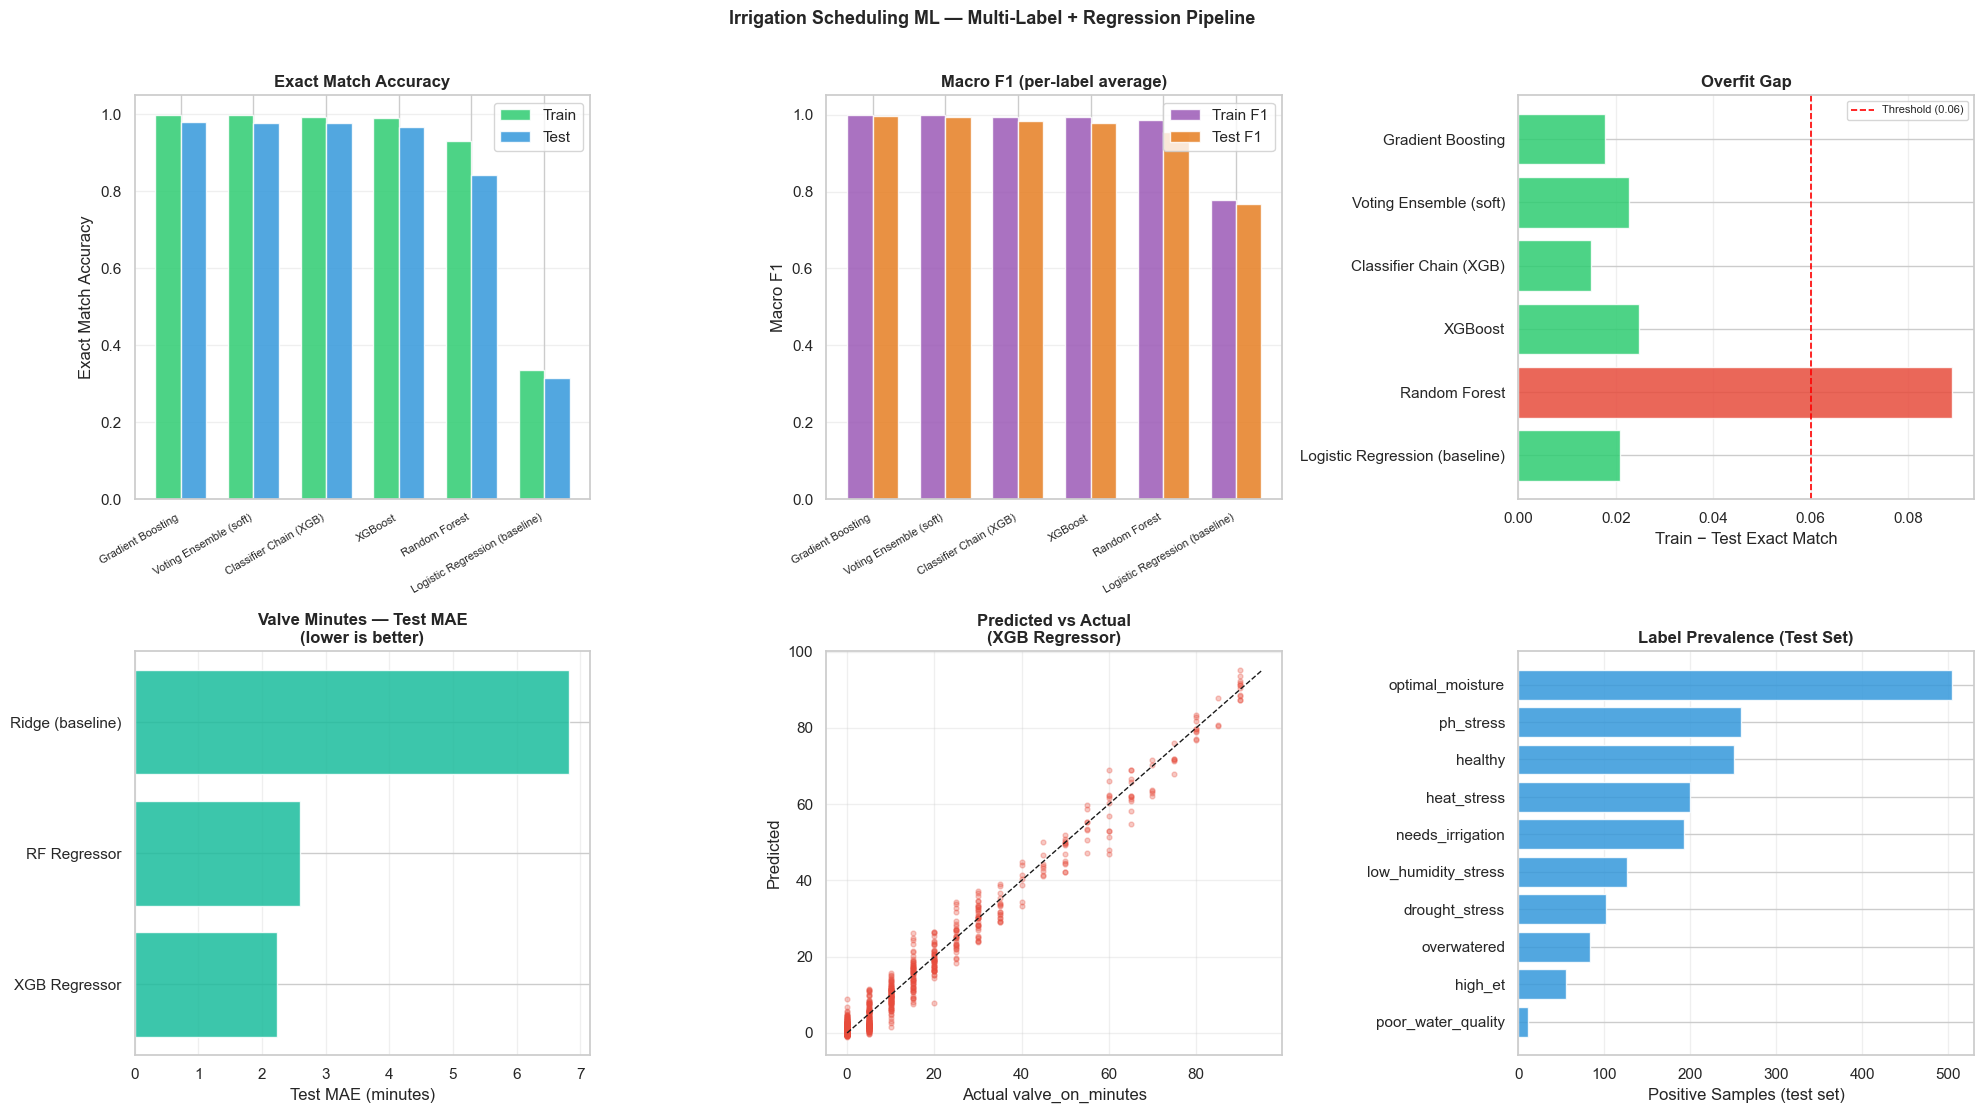

In [14]:
# BLOCK 13 — Visualisations
fig, axes = plt.subplots(2, 3, figsize=(20, 11))
models = cmp_df["Model"]
x = np.arange(len(models))
w = 0.35

# Plot 1: Exact Match
ax = axes[0,0]
ax.bar(x-w/2, cmp_df["Train Exact"], w, label="Train", color="#2ecc71", alpha=0.85)
ax.bar(x+w/2, cmp_df["Test Exact"],  w, label="Test",  color="#3498db", alpha=0.85)
ax.set_xticks(x); ax.set_xticklabels(models, rotation=30, ha="right", fontsize=8)
ax.set_ylabel("Exact Match Accuracy"); ax.set_title("Exact Match Accuracy", fontweight="bold")
ax.legend(); ax.grid(axis="y", alpha=0.3)

# Plot 2: Macro F1
ax2 = axes[0,1]
ax2.bar(x-w/2, cmp_df["Train F1"], w, label="Train F1", color="#9b59b6", alpha=0.85)
ax2.bar(x+w/2, cmp_df["Test F1"],  w, label="Test F1",  color="#e67e22", alpha=0.85)
ax2.set_xticks(x); ax2.set_xticklabels(models, rotation=30, ha="right", fontsize=8)
ax2.set_ylabel("Macro F1"); ax2.set_title("Macro F1 (per-label average)", fontweight="bold")
ax2.legend(); ax2.grid(axis="y", alpha=0.3)

# Plot 3: Overfit Gap
gap_colors = ["#e74c3c" if g > 0.06 else "#2ecc71" for g in cmp_df["Overfit Gap"]]
ax3 = axes[0,2]
ax3.barh(models[::-1], cmp_df["Overfit Gap"][::-1], color=gap_colors[::-1], alpha=0.85)
ax3.axvline(0.06, color="red", linestyle="--", lw=1.2, label="Threshold (0.06)")
ax3.set_xlabel("Train − Test Exact Match"); ax3.set_title("Overfit Gap", fontweight="bold")
ax3.legend(fontsize=8); ax3.grid(axis="x", alpha=0.3)

# Plot 4: Regression MAE comparison
ax4 = axes[1,0]
reg_names = reg_df["Model"]
ax4.barh(reg_names, reg_df["Test MAE"], color="#1abc9c", alpha=0.85)
ax4.set_xlabel("Test MAE (minutes)"); ax4.set_title("Valve Minutes — Test MAE\n(lower is better)", fontweight="bold")
ax4.grid(axis="x", alpha=0.3)

# Plot 5: Regression Actual vs Predicted (best model)
ax5 = axes[1,1]
best_reg = reg_results[reg_df.index[0]]
ax5.scatter(yr_te, best_reg["_pred"], alpha=0.3, s=12, color="#e74c3c")
lim = (0, 95)
ax5.plot(lim, lim, 'k--', lw=1)
ax5.set_xlabel("Actual valve_on_minutes"); ax5.set_ylabel("Predicted")
ax5.set_title(f"Predicted vs Actual\n({reg_df.iloc[0]['Model']})", fontweight="bold")
ax5.grid(alpha=0.3)

# Plot 6: Condition prevalence bar
ax6 = axes[1,2]
from sklearn.datasets import make_multilabel_classification
label_counts = Y_te.sum().sort_values(ascending=True)
ax6.barh(label_counts.index, label_counts.values, color="#3498db", alpha=0.85)
ax6.set_xlabel("Positive Samples (test set)")
ax6.set_title("Label Prevalence (Test Set)", fontweight="bold")
ax6.grid(axis="x", alpha=0.3)

plt.suptitle("Irrigation Scheduling ML — Multi-Label + Regression Pipeline",
             fontsize=13, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig("irrigation_ml_results.png", dpi=150, bbox_inches="tight")
print("\n✓ Chart saved: irrigation_ml_results.png")
plt.show()


In [15]:
# BLOCK 14 — Per-Label Report for Best Classifier
best_name = cmp_df.iloc[0]["Model"]
best_res  = next(r for r in all_clf_res if r["Model"] == best_name)

print(f"BEST CLASSIFIER — PER-LABEL REPORT")
print(f"\n  {best_name}")
print(f"    Test Exact Match : {best_res['Test Exact']:.4f}")
print(f"    Test Macro F1    : {best_res['Test F1']:.4f}")
print(f"    Hamming Loss     : {best_res['Hamming Loss']:.4f}\n")
print(classification_report(Y_te, best_res["_pred"],
                             target_names=LABEL_COLS, zero_division=0))

BEST CLASSIFIER — PER-LABEL REPORT

  Gradient Boosting
    Test Exact Match : 0.9812
    Test Macro F1    : 0.9955
    Hamming Loss     : 0.0024

                     precision    recall  f1-score   support

   needs_irrigation       0.99      1.00      0.99       193
        overwatered       1.00      0.99      0.99        84
     drought_stress       1.00      1.00      1.00       102
            high_et       1.00      1.00      1.00        55
   optimal_moisture       1.00      1.00      1.00       505
          ph_stress       1.00      1.00      1.00       259
 poor_water_quality       1.00      1.00      1.00        11
        heat_stress       1.00      1.00      1.00       200
low_humidity_stress       0.99      0.99      0.99       127
            healthy       0.98      0.98      0.98       251

          micro avg       0.99      0.99      0.99      1787
          macro avg       1.00      1.00      1.00      1787
       weighted avg       0.99      0.99      0.99      17

In [16]:
# BLOCK 15 — Feature Importance (from RF regressor on valve_on_minutes)
print("FEATURE IMPORTANCE (RF → valve_on_minutes)\n")
fi = pd.Series(rf_reg.feature_importances_, index=FEATURE_COLS).sort_values(ascending=False)
print(fi.head(15).to_string())


FEATURE IMPORTANCE (RF → valve_on_minutes)

soil_moisture              0.860388
growth_stage_flowering     0.029362
crop_type_rice             0.025817
time_since_irrigation      0.021632
crop_type_sugarcane        0.014396
growth_stage_vegetative    0.008746
crop_type_vegetables       0.007985
crop_type_cotton           0.007610
solar_radiation            0.005043
growth_stage_seedling      0.004468
crop_type_wheat            0.003595
wind_speed                 0.001799
soil_ph                    0.001672
humidity                   0.001567
water_tds                  0.001474
